# Yol Kazası Riskini Tahmin Etme

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSq-bE3oXRQNxyl288sDzDBzqjL48vcQW8g_w&s">

Bu projede, yol, çevresel ve trafik koşullarına ait çeşitli değişkenler kullanılarak, belirli bir senaryo altında meydana gelebilecek trafik kazasının risk düzeyini tahmin edebilen bir makine öğrenmesi modeli geliştirilmesi amaçlanmaktadır.

**road_type:** Yolun otoyol, şehir içi yol veya kırsal yol gibi yapısal türünü ifade eder.

**num_lanes**: Yol üzerinde bulunan toplam şerit sayısını belirtir.

**curvature:** Yolun düz mü yoksa virajlı mı olduğunu gösteren geometrik eğrilik bilgisini temsil eder.

**speed_limit:** İlgili yol kesimi için belirlenmiş maksimum yasal hız sınırını ifade eder.

**lighting:** Yolun aydınlatma durumunu (gündüz, gece aydınlatmalı veya karanlık) belirtir.

**weather:** Sürüş esnasındaki hava koşullarını (güneşli, yağmurlu, sisli vb.) temsil eder.

**road_signs_present:** Yol üzerinde trafik levhalarının bulunup bulunmadığını gösterir.

**public_road:** Yolun kamuya açık bir yol olup olmadığını ifade eden ikili (boolean) bir değişkendir.

**time_of_day:** Kazanın veya sürüş senaryosunun gerçekleştiği zaman dilimini (sabah, öğle, akşam, gece) belirtir.

**holiday:** İncelenen zamanın resmi tatil gününe denk gelip gelmediğini gösterir.

**school_season:** Okulların açık olduğu dönemde mi yoksa tatil döneminde mi olunduğunu ifade eder.

**num_reported_accidents:** İlgili yol ve koşullarda daha önce raporlanmış kaza sayısını temsil eder.

**accident_risk:** Tüm bu değişkenler dikkate alınarak hesaplanan, kazanın meydana gelme olasılığını temsil eden sürekli risk skorudur.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_10k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_2k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_100k.csv
/kaggle/input/road-accident-casualties-eda/__results__.html
/kaggle/input/road-accident-casualties-eda/__resultx__.html
/kaggle/input/road-accident-casualties-eda/__notebook__.ipynb
/kaggle/input/road-accident-casualties-eda/__output__.json
/kaggle/input/road-accident-casualties-eda/custom.css
/kaggle/input/road-accident-casualties-eda/__results___files/__results___25_0.png
/kaggle/input/road-accident-casualties-eda/__results___files/__results___14_0.png
/kaggle/input/road-accident-casualties-eda/__results___files/__results___19_0.png
/kaggle/input/road-accident-casualties-eda/__results___files/__results___31_0.png
/kaggle/input/road-accident-casualties-eda/__results___files/__results___22_0.png
/kaggle/input/road-accident-casualties-eda/__results___files/__r

### Veri Seti Kaynağı

https://www.kaggle.com/datasets/ianktoo/simulated-roads-accident-data


In [2]:

import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [3]:
# Dataset yolu
data_path = "/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_100k.csv"

# Dataset'i oku
df = pd.read_csv(data_path)

# İlk 5 satırı görüntüle
df.head()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,False,True,evening,False,False,1,0.64
1,highway,1,0.34,25,dim,clear,False,False,morning,False,False,3,0.27
2,rural,2,0.76,70,night,foggy,True,False,evening,True,True,1,0.76
3,rural,3,0.37,70,night,foggy,True,False,morning,False,True,0,0.60
4,highway,3,0.39,45,dim,rainy,False,True,morning,False,False,0,0.17


In [4]:
df.shape

(100000, 13)

In [5]:
df.columns

Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [6]:
df.isnull().sum()

road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [7]:
df.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2.495300,0.500619,47.054550,1.50308,0.382613
std,1.117958,0.288691,16.321527,1.22866,0.178692
min,1.000000,0.000000,25.000000,0.00000,0.000000
25%,1.000000,0.250000,35.000000,1.00000,0.250000
50%,2.000000,0.500000,45.000000,1.00000,0.380000
75%,3.000000,0.750000,60.000000,2.00000,0.510000
max,4.000000,1.000000,70.000000,10.00000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               100000 non-null  object 
 1   num_lanes               100000 non-null  int64  
 2   curvature               100000 non-null  float64
 3   speed_limit             100000 non-null  int64  
 4   lighting                100000 non-null  object 
 5   weather                 100000 non-null  object 
 6   road_signs_present      100000 non-null  bool   
 7   public_road             100000 non-null  bool   
 8   time_of_day             100000 non-null  object 
 9   holiday                 100000 non-null  bool   
 10  school_season           100000 non-null  bool   
 11  num_reported_accidents  100000 non-null  int64  
 12  accident_risk           100000 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 7.2+ MB


In [9]:
df.corr(numeric_only=True)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
num_lanes,1.000000,-0.002669,0.000764,-0.000965,-0.001558,-0.000515,-0.000786,0.003680,0.002335
curvature,-0.002669,1.000000,-0.001403,-0.000314,-0.000070,-0.000924,-0.000934,0.001739,0.479614
speed_limit,0.000764,-0.001403,1.000000,0.000696,-0.000631,-0.002766,0.000700,-0.002247,0.493560
road_signs_present,-0.000965,-0.000314,0.000696,1.000000,0.007141,-0.002622,0.001860,0.001025,0.000451
public_road,-0.001558,-0.000070,-0.000631,0.007141,1.000000,-0.000702,-0.000884,-0.007474,-0.004570
holiday,-0.000515,-0.000924,-0.002766,-0.002622,-0.000702,1.000000,-0.002387,0.001129,-0.003658
school_season,-0.000786,-0.000934,0.000700,0.001860,-0.000884,-0.002387,1.000000,0.001185,-0.001547
num_reported_accidents,0.003680,0.001739,-0.002247,0.001025,-0.007474,0.001129,0.001185,1.000000,0.171228
accident_risk,0.002335,0.479614,0.493560,0.000451,-0.004570,-0.003658,-0.001547,0.171228,1.000000


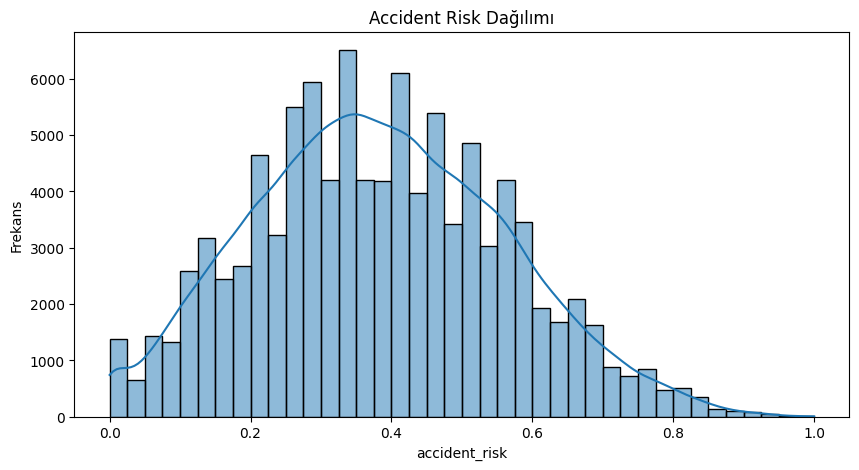

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df["accident_risk"], kde=True, bins=40)
plt.title("Accident Risk Dağılımı")
plt.xlabel("accident_risk")
plt.ylabel("Frekans")
plt.show()


Accident_risk değişkeninin dağılımı incelendiğinde, risk değerlerinin ağırlıklı olarak orta seviyelerde yoğunlaştığı ve sağa çarpık bir dağılım gösterdiği görülmektedir.

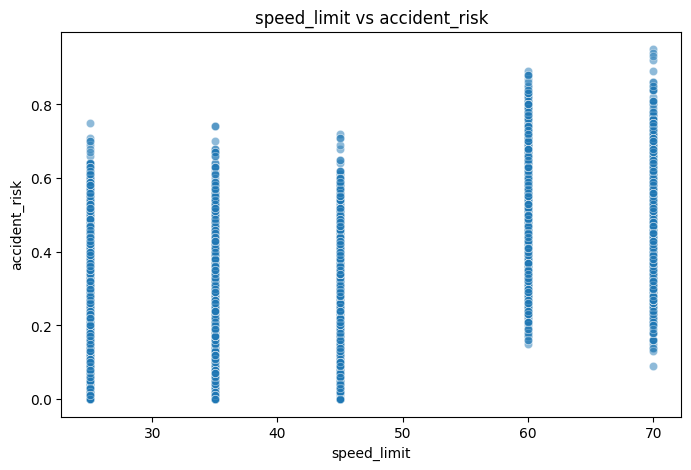

In [11]:
sample_df = df.sample(5000, random_state=42)  # hız için yeterli bir örnek

plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df, x="speed_limit", y="accident_risk", alpha=0.5)
plt.title("speed_limit vs accident_risk")
plt.show()


Hız sınırı arttıkça kaza riskinin genel olarak yükseldiği ve özellikle yüksek hız limitlerinde risk değerlerinin daha geniş bir aralığa yayıldığı gözlemlenmektedir.

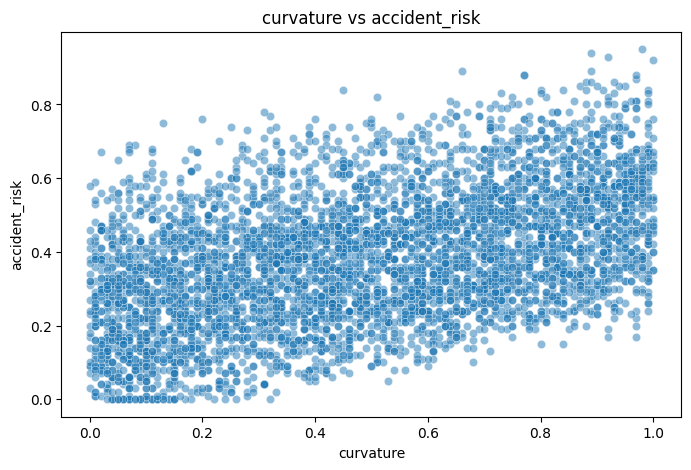

In [12]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df, x="curvature", y="accident_risk", alpha=0.5)
plt.title("curvature vs accident_risk")
plt.show()


Yol eğriliği (curvature) arttıkça accident_risk değerlerinin belirgin şekilde yükseldiği, virajlı yolların daha yüksek kaza riski taşıdığı görülmektedir.

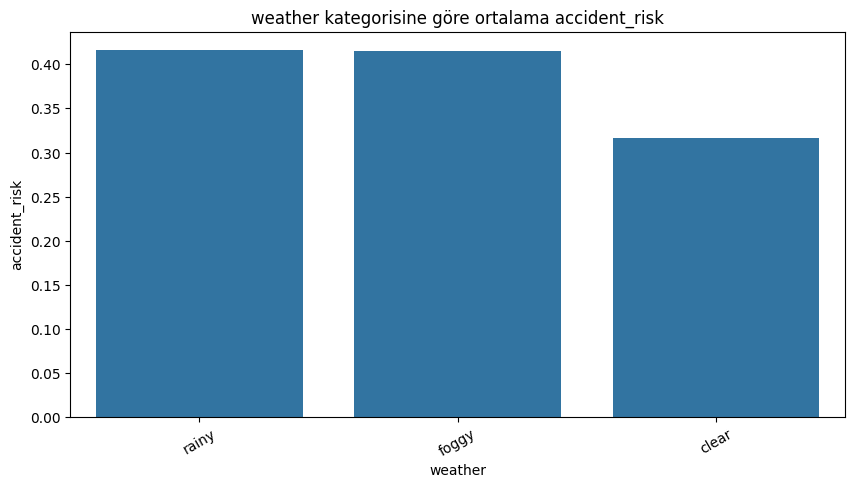

In [13]:
plt.figure(figsize=(10,5))
order = df.groupby("weather")["accident_risk"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="weather", y="accident_risk", order=order, errorbar=None)
plt.title("weather kategorisine göre ortalama accident_risk")
plt.xticks(rotation=30)
plt.show()


Sisli ve yağmurlu hava koşullarında ortalama kaza riskinin açık hava koşullarına kıyasla daha yüksek olduğu gözlemlenmiştir.

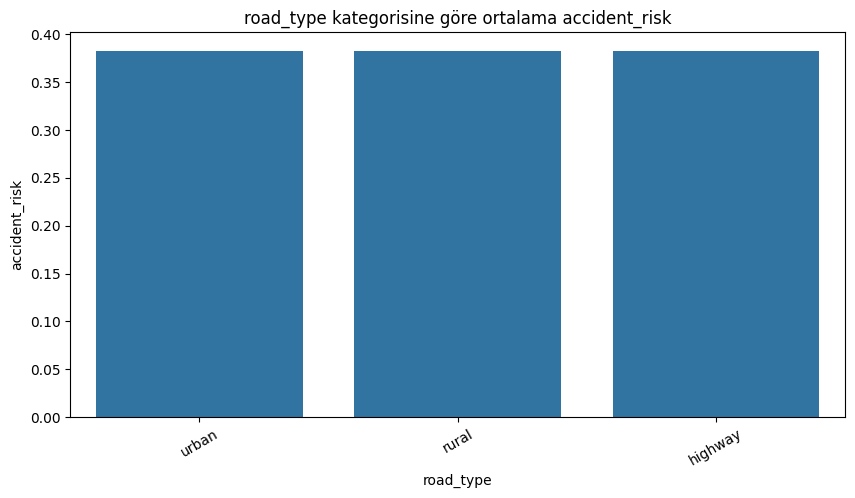

In [14]:
plt.figure(figsize=(10,5))
order = df.groupby("road_type")["accident_risk"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="road_type", y="accident_risk", order=order, errorbar=None)
plt.title("road_type kategorisine göre ortalama accident_risk")
plt.xticks(rotation=30)
plt.show()


Yol türleri arasında ortalama kaza riski değerleri birbirine yakın.

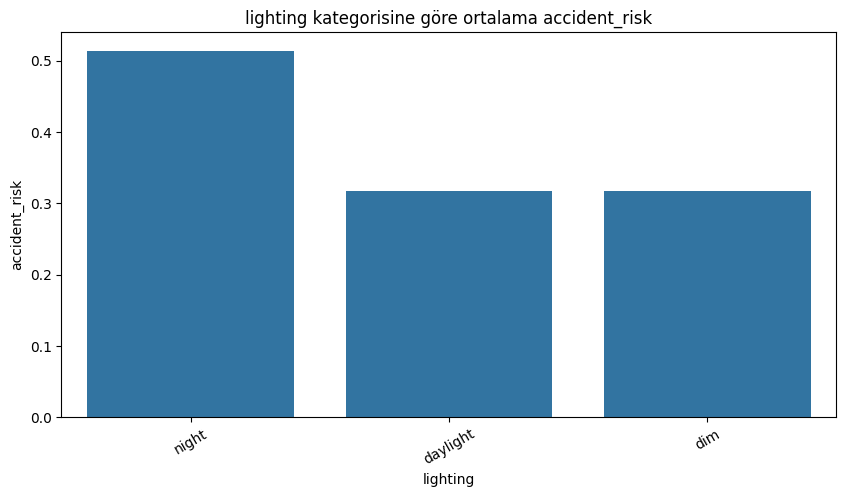

In [15]:
plt.figure(figsize=(10,5))
order = df.groupby("lighting")["accident_risk"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="lighting", y="accident_risk", order=order, errorbar=None)
plt.title("lighting kategorisine göre ortalama accident_risk")
plt.xticks(rotation=30)
plt.show()


Gece koşullarında kaza riskinin gündüz ve loş aydınlatmalı ortamlara kıyasla belirgin şekilde daha yüksek olduğu tespit edilmiştir.

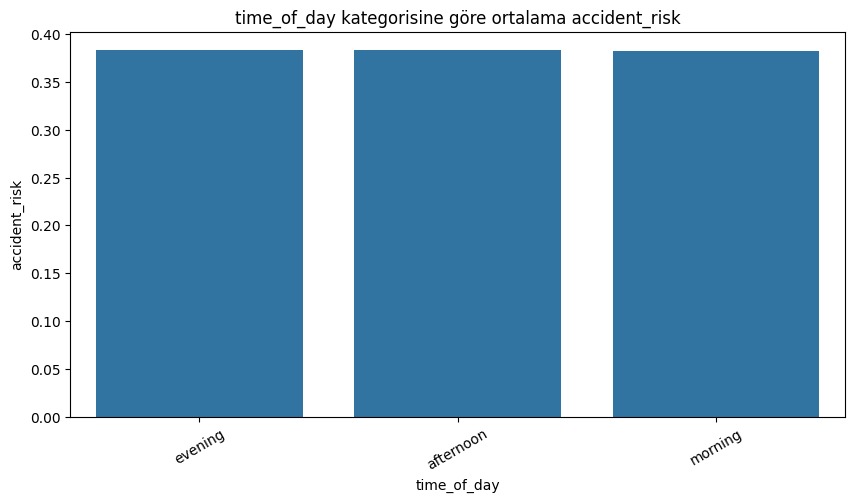

''

In [16]:
plt.figure(figsize=(10,5))
order = df.groupby("time_of_day")["accident_risk"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="time_of_day", y="accident_risk", order=order, errorbar=None)
plt.title("time_of_day kategorisine göre ortalama accident_risk")
plt.xticks(rotation=30)
plt.show()
;

Günün farklı zaman dilimleri arasında kaza riski açısından büyük farklar bulunmamakla birlikte, akşam ve öğle saatlerinde riskin nispeten daha yüksek olduğu gözlemlenmektedir.

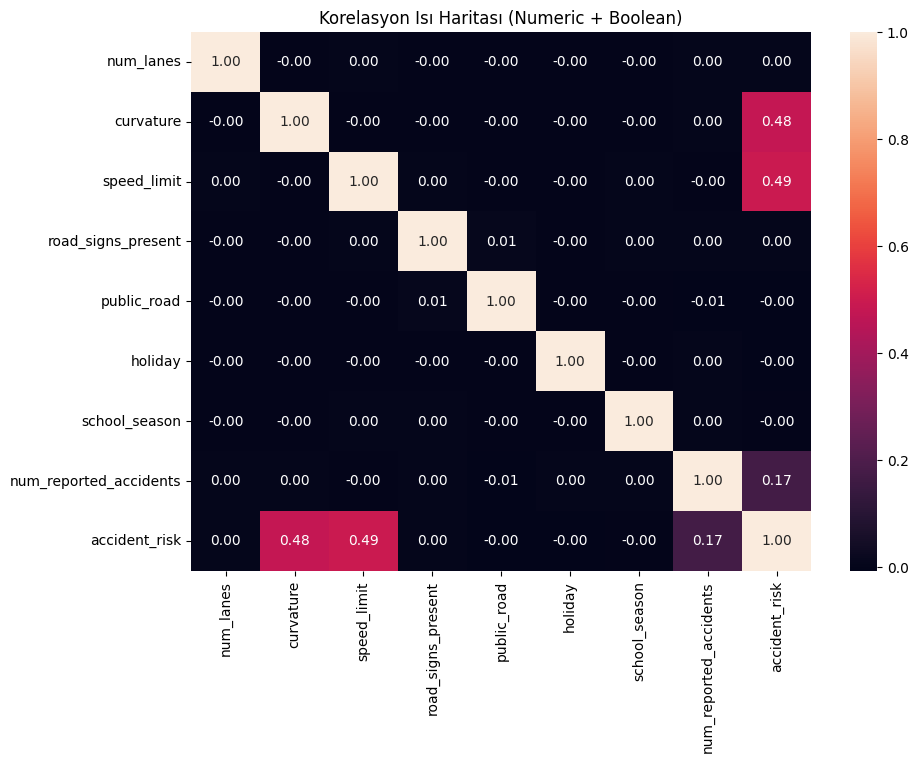

In [17]:
num_bool_df = df.select_dtypes(include=["int64", "float64", "bool"])

plt.figure(figsize=(10,7))
sns.heatmap(num_bool_df.corr(), annot=True, fmt=".2f")
plt.title("Korelasyon Isı Haritası (Numeric + Boolean)")
plt.show()


Korelasyon analizi sonucunda, accident_risk değişkeninin özellikle curvature ve speed_limit ile orta düzeyde pozitif ilişki gösterdiği, diğer değişkenlerle olan ilişkinin ise zayıf olduğu belirlenmiştir.

### Encoding

In [18]:
# ==============================
# Kategorik sütunlar
# ==============================
categorical_columns = [
    "road_type",
    "lighting",
    "weather",
    "time_of_day"
]

# ==============================
# One-Hot Encoding
# ==============================
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True  # dummy trap önlemek için
)

# Son haline bakalım
df_encoded.head()


,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,2,0.29,70,False,True,False,False,1,0.64,True,False,False,True,False,True,True,False
1,1,0.34,25,False,False,False,False,3,0.27,False,False,True,False,False,False,False,True
2,2,0.76,70,True,False,True,True,1,0.76,True,False,False,True,True,False,True,False
3,3,0.37,70,True,False,False,True,0,0.60,True,False,False,True,True,False,False,True
4,3,0.39,45,False,True,False,False,0,0.17,False,False,True,False,False,True,False,True


In [19]:
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   num_lanes               100000 non-null  int64  
 1   curvature               100000 non-null  float64
 2   speed_limit             100000 non-null  int64  
 3   road_signs_present      100000 non-null  bool   
 4   public_road             100000 non-null  bool   
 5   holiday                 100000 non-null  bool   
 6   school_season           100000 non-null  bool   
 7   num_reported_accidents  100000 non-null  int64  
 8   accident_risk           100000 non-null  float64
 9   road_type_rural         100000 non-null  bool   
 10  road_type_urban         100000 non-null  bool   
 11  lighting_dim            100000 non-null  bool   
 12  lighting_night          100000 non-null  bool   
 13  weather_foggy           100000 non-null  bool   
 14  weather_rainy        

In [20]:
# ==============================
# Feature ve Target Ayrımı
# ==============================

x = df_encoded.drop("accident_risk", axis=1)
y = df_encoded["accident_risk"]

print("X shape:", x.shape)
print("y shape:", y.shape)


X shape: (100000, 16)
y shape: (100000,)


In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Eğitim seti:", x_train.shape)
print("Test seti:", x_test.shape)


Eğitim seti: (80000, 16)
Test seti: (20000, 16)


In [22]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor()
model.fit(x_train, y_train)
tahmin1 = model.predict(x_test)
r2 = r2_score(y_test, tahmin1)

In [23]:
r2

0.9115207581161209

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

tahmin2 = model.predict(x_test)
r2_lr = r2_score(y_test, tahmin2)

r2_lr


0.8440326049305855

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(x_train, y_train)

tahmin3 = model.predict(x_test)
r2_gb = r2_score(y_test, tahmin3)

r2_gb


0.9211313166242532

In [26]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(random_state=42)
model.fit(x_train, y_train)

tahmin4 = model.predict(x_test)
r2_et = r2_score(y_test, tahmin4)

r2_et


0.9060804655329171

In [27]:
print("Linear Regression R2       :", r2_lr)
print("Random Forest R2           :", r2)
print("Gradient Boosting R2       :", r2_gb)
print("Extra Trees R2             :", r2_et)


Linear Regression R2       : 0.8440326049305855
Random Forest R2           : 0.9115207581161209
Gradient Boosting R2       : 0.9211313166242532
Extra Trees R2             : 0.9060804655329171


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np


def algo_test(x, y):
    # ==============================
    # Modeller
    # ==============================
    L   = LinearRegression()
    R   = Ridge()
    Lass= Lasso()
    E   = ElasticNet()
    ETR = ExtraTreesRegressor(random_state=42)
    GBR = GradientBoostingRegressor(random_state=42)
    kn  = KNeighborsRegressor()
    dt  = DecisionTreeRegressor(random_state=42)

    algos = [L, R, Lass, E, ETR, GBR, kn, dt]
    algo_names = [
        'Linear Regression',
        'Ridge',
        'Lasso',
        'ElasticNet',
        'Extra Trees',
        'Gradient Boosting',
        'KNeighborsRegressor',
        'Decision Tree'
    ]

    # ==============================
    # Train-Test Split
    # ==============================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    r_squared = []
    rmse = []
    mae = []

    # ==============================
    # Sonuç tablosu
    # ==============================
    result = pd.DataFrame(
        columns=['R_Squared', 'RMSE', 'MAE'],
        index=algo_names
    )

    # ==============================
    # Model eğitimi ve değerlendirme
    # ==============================
    for algo in algos:
        y_pred = algo.fit(x_train, y_train).predict(x_test)

        r_squared.append(r2_score(y_test, y_pred))
        rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae.append(mean_absolute_error(y_test, y_pred))

    result['R_Squared'] = r_squared
    result['RMSE'] = rmse
    result['MAE'] = mae

    # R² değerine göre sırala
    rtable = result.sort_values('R_Squared', ascending=False)

    return rtable


In [29]:
algo_test(x, y)


,R_Squared,RMSE,MAE
Gradient Boosting,0.921131,0.049807,0.039795
Extra Trees,0.906080,0.054352,0.043355
Ridge,0.844033,0.070041,0.056420
Linear Regression,0.844033,0.070041,0.056420
Decision Tree,0.825161,0.074157,0.059142
KNeighborsRegressor,0.782497,0.082712,0.065308
ElasticNet,0.213623,0.157272,0.127443
Lasso,0.127120,0.165696,0.134359


# Örnek risk tahmini

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

final_model = GradientBoostingRegressor(random_state=42)
final_model.fit(x, y)


GradientBoostingRegressor(random_state=42)

In [31]:
# Bu kod, belirli yol, çevre ve trafik koşullarını temsil eden tek bir senaryoyu, daha önce eğitilmiş modele uygun sayısal formata dönüştürerek kaza riski tahmini yapılmasını sağlar.

new_sample = pd.DataFrame([{ # Tek satırlık (1 gözlem) bir DataFrame oluşturuyor. Modelime bir tane yeni yol durumu veriyorum ve bu durum için kaza riskini tahmin etmesini istiyorum.
    "num_lanes": 2,
    "curvature": 0.7,
    "speed_limit": 70,
    "road_signs_present": True,
    "public_road": True,
    "holiday": False,
    "school_season": True,
    "num_reported_accidents": 5,

    # One-Hot sütunlar
    "road_type_rural": False,
    "road_type_urban": False,      # ikisi de False → highway
    "lighting_dim": False,
    "lighting_night": True,        # night
    "weather_foggy": False,
    "weather_rainy": True,         # rainy
    "time_of_day_evening": True,
    "time_of_day_morning": False   # afternoon = False, False
}])


In [32]:
predicted_risk = final_model.predict(new_sample)

predicted_risk


array([0.81185472])

### Tahmin yorumlayalım

In [33]:
risk_value = predicted_risk[0]

if risk_value < 0.3:
    risk_level = "Düşük Risk"
elif risk_value < 0.6:
    risk_level = "Orta Risk"
else:
    risk_level = "Yüksek Risk"

print(f"Tahmin Edilen Kaza Riski: {risk_value:.2f}")
print(f"Risk Seviyesi: {risk_level}")

# Bu eşikler (0.3 / 0.6) senin benim seçtiğim sınırlardır; veri seti “düşük/orta/yüksek” etiketli olmadığı için bunlar yorumlama amaçlı kullanılır (bu da gayet doğru bir yaklaşım).

Tahmin Edilen Kaza Riski: 0.81
Risk Seviyesi: Yüksek Risk


## Kullanıcıdan bilgi alarak tahmin yapalım.

In [34]:
print("Lütfen yol ve çevre koşullarını giriniz.\n")

num_lanes = int(input("Şerit sayısı (örn: 2): "))
curvature = float(input("Yol eğriliği (0 = düz, 1 = çok virajlı): "))
speed_limit = int(input("Hız sınırı (örn: 70): "))

road_signs_present = input("Trafik levhası var mı? (E/H): ").strip().lower() == "e"
public_road = input("Yol kamuya açık mı? (E/H): ").strip().lower() == "e"
holiday = input("Bugün tatil mi? (E/H): ").strip().lower() == "e"
school_season = input("Okullar açık mı? (E/H): ").strip().lower() == "e"

num_reported_accidents = int(input("Daha önce raporlanan kaza sayısı (örn: 5): "))


Lütfen yol ve çevre koşullarını giriniz.



StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [ ]:
print("\nYol tipi seçiniz: highway / urban / rural")
road_type = input("Yol tipi: ").strip().lower()

print("\nAydınlatma durumu: daylight / dim / night")
lighting = input("Aydınlatma durumu: ").strip().lower()

print("\nHava durumu: clear / rainy / foggy")
weather = input("Hava durumu: ").strip().lower()

print("\nGünün zamanı: morning / afternoon / evening")
time_of_day = input("Günün zamanı: ").strip().lower()


In [ ]:
new_sample = pd.DataFrame([{
    "num_lanes": num_lanes,
    "curvature": curvature,
    "speed_limit": speed_limit,
    "road_signs_present": road_signs_present,
    "public_road": public_road,
    "holiday": holiday,
    "school_season": school_season,
    "num_reported_accidents": num_reported_accidents,

    # road_type (referans: highway)
    "road_type_rural": road_type == "rural",
    "road_type_urban": road_type == "urban",

    # lighting (referans: daylight)
    "lighting_dim": lighting == "dim",
    "lighting_night": lighting == "night",

    # weather (referans: clear)
    "weather_foggy": weather == "foggy",
    "weather_rainy": weather == "rainy",

    # time_of_day (referans: afternoon)
    "time_of_day_evening": time_of_day == "evening",
    "time_of_day_morning": time_of_day == "morning"
}])


In [ ]:
predicted_risk = final_model.predict(new_sample)
risk_value = predicted_risk[0]

if risk_value < 0.3:
    risk_level = "Düşük Risk"
elif risk_value < 0.6:
    risk_level = "Orta Risk"
else:
    risk_level = "Yüksek Risk"

print(f"\nTahmin Edilen Kaza Riski: {risk_value:.2f}")
print(f"Risk Seviyesi: {risk_level}")


Eğitilen Gradient Boosting modeli kullanılarak oluşturulan örnek bir yol senaryosu için kaza riski tahmini yapılmış ve modelin, farklı yol ve çevresel koşullar altında risk seviyesini sayısal olarak başarıyla tahmin edebildiği gösterilmiştir.

## Sonuç

Deneysel sonuçlar incelendiğinde, ağaç tabanlı ensemble yöntemlerinin doğrusal modellere kıyasla daha yüksek tahmin performansı sunduğu, özellikle Gradient Boosting Regressor’ın R², RMSE ve MAE metriklerinin tümünde en iyi sonuçları elde ederek kaza riskinin tahmininde en etkili model olduğu görülmüştür. Bu bulgular, trafik kazası riskinin doğrusal olmayan ve karmaşık ilişkiler içerdiğini ve bu tür problemlerde ensemble tabanlı öğrenme yaklaşımlarının daha uygun olduğunu ortaya koymaktadır.